#**Task 1: Solar PV Daily Output Analysis**

Dataset (sample) – hourly solar output (kW) over a day:

Tasks:

1 - Plot PV_Output_kW vs Hour.

2 - Compute max, min, mean, median PV output.

3 - Find hours when PV output > 50 kW.

4 - Fit a simple sinusoidal curve to approximate daily PV output.

Text(0.5, 1.0, 'PV Output vs Hour')

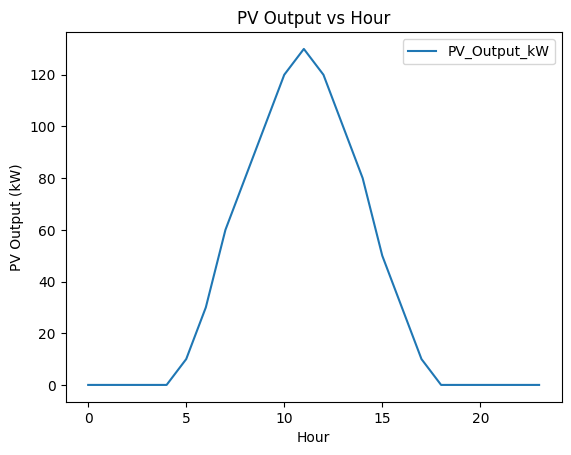

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hour': np.arange(0,24),
    'PV_Output_kW': [0,0,0,0,0,10,30,60,80,100,120,130,120,100,80,50,30,10,0,0,0,0,0,0]
}

df = pd.DataFrame(data)

# Plot PV_Output_kW vs Hour.

df.plot(x='Hour', y='PV_Output_kW', kind='line')
plt.xlabel('Hour')
plt.ylabel('PV Output (kW)')
plt.title('PV Output vs Hour')



In [14]:

# Compute max, min, mean, median PV output.

max_PV = df['PV_Output_kW'].max()
min_PV = df['PV_Output_kW'].min()
mean_PV = df['PV_Output_kW'].mean()
median_PV = df['PV_Output_kW'].median()

print(f'Max PV Output: {max_PV} kW')
print(f'Min PV Output: {min_PV} kW')
print(f'Mean PV Output: {mean_PV} kW')
print(f'Median PV Output: {median_PV} kW')

Max PV Output: 130 kW
Min PV Output: 0 kW
Mean PV Output: 38.333333333333336 kW
Median PV Output: 10.0 kW


In [22]:
#Find hours when PV output > 50 kW.

hours_above_50 = df[df['PV_Output_kW'] > 50]

print('Hours when PV output > 50 kW:')
print(hours_above_50)


Hours when PV output > 50 kW:
    Hour  PV_Output_kW
7      7            60
8      8            80
9      9           100
10    10           120
11    11           130
12    12           120
13    13           100
14    14            80
Hours with output > 50 kW: [7, 8, 9, 10, 11, 12, 13, 14]


In [23]:
high_output_hours = df[df['PV_Output_kW'] > 50]['Hour']
print(f"Hours with output > 50 kW: {high_output_hours.tolist()}")

Hours with output > 50 kW: [7, 8, 9, 10, 11, 12, 13, 14]


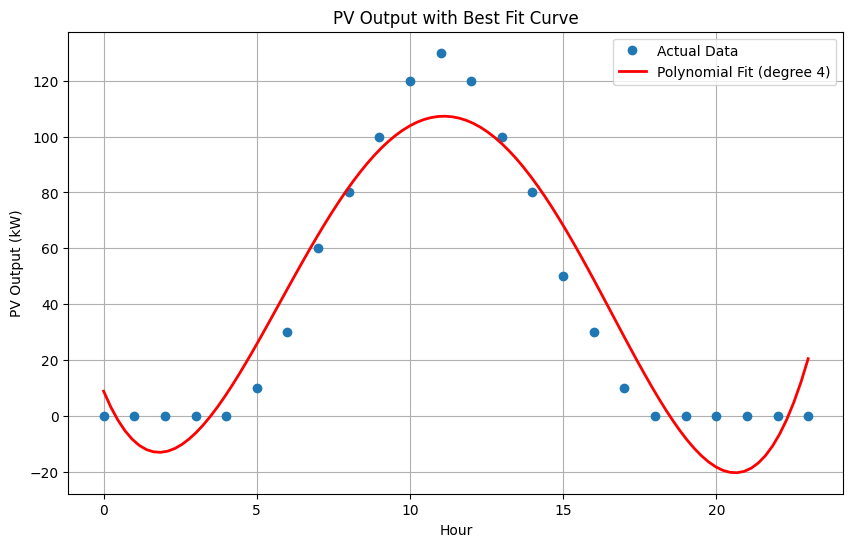

In [39]:

degree = 4  #produces quite accurate best-fit graph for Solar-sinusoidal data
coefficients = np.polyfit(df['Hour'], df['PV_Output_kW'], degree)
poly_function = np.poly1d(coefficients)

# Generate smooth curve
hours_smooth = np.linspace(0, 23, 100)
fitted_values = poly_function(hours_smooth)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['Hour'], df['PV_Output_kW'], 'o', label='Actual Data')
plt.plot(hours_smooth, fitted_values, 'r-', label=f'Polynomial Fit (degree {degree})', linewidth=2)
plt.xlabel('Hour')
plt.ylabel('PV Output (kW)')
plt.title('PV Output with Best Fit Curve')
plt.legend()
plt.grid(True)
plt.show()



---



#**Task 2: Wind Speed and Power Analysis**



Dataset (sample) – hourly wind speed and turbine output:

Tasks:

Plot Wind_Speed vs Turbine_Power.

Calculate average wind speed and total daily energy produced (sum of hourly power).

Identify hours when turbine power > 50 kW.

Try scatter plot with regression line of wind speed vs turbine power.

Text(0.5, 1.0, 'Wind Speed vs Turbine Power')

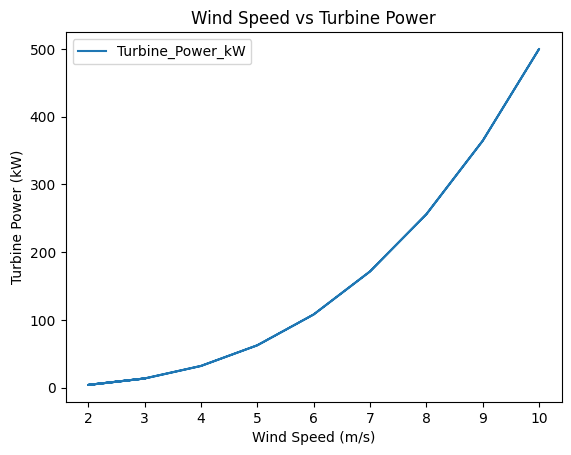

In [40]:
data = {
    'Hour': np.arange(0,24),
    'Wind_Speed_m_s': [3,2,2,3,4,5,6,7,8,9,10,9,8,7,6,5,4,3,3,2,2,2,2,3],
}

df = pd.DataFrame(data)
# Simplified turbine power curve (linear approximation)
df['Turbine_Power_kW'] = df['Wind_Speed_m_s']**3 * 0.5

df.plot(x='Wind_Speed_m_s', y='Turbine_Power_kW', kind='line')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Turbine Power (kW)')
plt.title('Wind Speed vs Turbine Power')


In [43]:
#Calculate average wind speed and total daily energy produced (sum of hourly power).

average_wind_speed = df['Wind_Speed_m_s'].mean()
total_energy_produced = df['Turbine_Power_kW'].sum()

print(f'Average Wind Speed: {average_wind_speed} m/s')
print(f'Total Daily Energy Produced: {total_energy_produced} kW')


Average Wind Speed: 4.791666666666667 m/s
Total Daily Energy Produced: 2580.5 kW


In [44]:
#Find hours when PV output > 50 kW.

power_hours_over_50 = df[df['Turbine_Power_kW'] > 50].Hour.tolist()
print(f"Hours with power > 50 kW: {power_hours_over_50}")

Hours with power > 50 kW: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


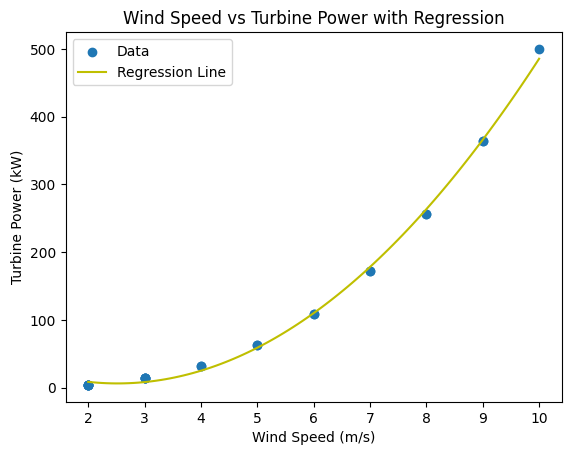

In [51]:
#Try scatter plot with regression line of wind speed vs turbine power.

# Calculate regression line
coefficients = np.polyfit(df['Wind_Speed_m_s'], df['Turbine_Power_kW'], 2)
poly_function = np.poly1d(coefficients)


x_line = np.linspace(df['Wind_Speed_m_s'].min(), df['Wind_Speed_m_s'].max(), 100)
y_line = poly_function(x_line)


plt.scatter(df['Wind_Speed_m_s'], df['Turbine_Power_kW'], label='Data')
plt.plot(x_line, y_line, 'y-', label='Regression Line')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Turbine Power (kW)')
plt.title('Wind Speed vs Turbine Power with Regression')
plt.legend()
plt.show()



---



#**Task 3: Electricity Demand vs Solar PV**


Dataset (sample) – 24 hours electricity demand and solar generation:

Tasks:

Plot Demand and PV on same graph.

Compute net demand = Demand – PV for each hour.

Identify peak net demand hours.

Calculate total PV contribution to daily demand (sum of PV / sum of Demand).

Text(0.5, 1.0, 'Electricity Demand vs Solar PV')

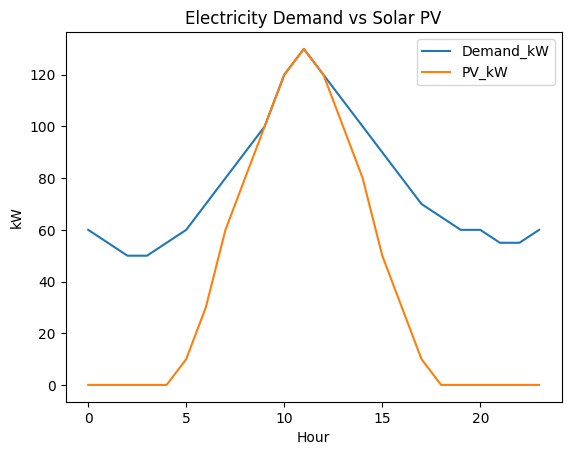

In [52]:
data = {
    'Hour': np.arange(0,24),
    'Demand_kW': [60,55,50,50,55,60,70,80,90,100,120,130,120,110,100,90,80,70,65,60,60,55,55,60],
    'PV_kW': [0,0,0,0,0,10,30,60,80,100,120,130,120,100,80,50,30,10,0,0,0,0,0,0]
}

df = pd.DataFrame(data)

df.plot(x='Hour', y=['Demand_kW', 'PV_kW'], kind='line')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.title('Electricity Demand vs Solar PV')


In [54]:
#Compute net demand = Demand – PV for each hour.

net_demand = df['Demand_kW'] - df['PV_kW']
df['Net_Demand_kW'] = net_demand

print(df)

    Hour  Demand_kW  PV_kW  Net_Demand_kW
0      0         60      0             60
1      1         55      0             55
2      2         50      0             50
3      3         50      0             50
4      4         55      0             55
5      5         60     10             50
6      6         70     30             40
7      7         80     60             20
8      8         90     80             10
9      9        100    100              0
10    10        120    120              0
11    11        130    130              0
12    12        120    120              0
13    13        110    100             10
14    14        100     80             20
15    15         90     50             40
16    16         80     30             50
17    17         70     10             60
18    18         65      0             65
19    19         60      0             60
20    20         60      0             60
21    21         55      0             55
22    22         55      0        

In [56]:
#Identify peak net demand hours.

peak_net_demand_value = df['Net_Demand_kW'].max()
peak_net_demand_hours = df[df['Net_Demand_kW'] == peak_net_demand_value]['Hour'].tolist()

print(f"Peak Net Demand Hours: {peak_net_demand_hours}")

Peak Net Demand Hours: [18]


In [57]:
#Calculate total PV contribution to daily demand (sum of PV / sum of Demand).

total_pv_contribution = df['PV_kW'].sum() / df['Demand_kW'].sum()
print(f"Total PV Contribution: {total_pv_contribution:.2%}")

Total PV Contribution: 49.86%


#**Task 4: Solar + Wind Demand & Consumption**

-Basic statistics

  Compute the mean, median, and standard deviation for PV_Production and Energy_Consumption.

-Total energy

  Calculate total energy produced and total energy consumed over the period.

-Net energy

  Create a new column Net_Energy = PV_Production - Energy_Consumption.

-Filter rows

  Filter all hours where Net_Energy is negative (consumption > production).

-Max/min values

  Find the time when PV_Production is maximum and minimum.

-Conditional column

  Add a column called Battery_Action that is "Charge" if Net_Energy > 0 else "Discharge".

-Plotting

  Plot PV_Production and Energy_Consumption on the same line chart over time.

-Correlation

  Compute the correlation between PV_Production and Solar_Irradiance.

-Temperature impact

  Create a scatter plot of PV_Production vs Temperature and observe the trend.

-Rolling average

  Compute a 3-hour rolling average of PV_Production and add it as a new column.

In [113]:
# ===== Sample Dataset =====
import pandas as pd

data = {
    "Time (h)": [0, 1, 2, 3, 4, 5, 6, 7],
    "Solar_Irradiance (W/m^2)": [0, 50, 120, 200, 300, 250, 180, 100],
    "PV_Production (kW)": [0, 0.8, 2.0, 3.5, 5.0, 4.2, 3.0, 1.5],
    "Energy_Consumption (kW)": [1.2, 1.0, 1.5, 2.0, 3.0, 2.5, 2.0, 1.8],
    "Temperature (°C)": [15, 16, 18, 20, 22, 21, 19, 17],
    "Wind_Speed (m/s)": [3.0, 3.5, 4.0, 5.0, 5.5, 4.8, 4.2, 3.6]
}

df = pd.DataFrame(data)
print(df)


   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
2         2                       120                 2.0   
3         3                       200                 3.5   
4         4                       300                 5.0   
5         5                       250                 4.2   
6         6                       180                 3.0   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  
0                      1.2                15               3.0  
1                      1.0                16               3.5  
2                      1.5                18               4.0  
3                      2.0                20               5.0  
4                      3.0                22               5.5  
5                      2.5                21               4

In [114]:
#Compute the mean, median, and standard deviation for PV_Production (kW) and Energy_Consumption (kW).

pv_mean = df['PV_Production (kW)'].mean()
pv_median = df['PV_Production (kW)'].median()
pv_std = df['PV_Production (kW)'].std()

ec_mean = df['Energy_Consumption (kW)'].mean()
ec_median = df['Energy_Consumption (kW)'].median()
ec_std = df['Energy_Consumption (kW)'].std()

print(f"PV_Production (kW) Mean: {pv_mean}")
print(f"PV_Production (kW) Median: {pv_median}")
print(f"PV_Production (kW) Standard Deviation: {pv_std}")
print(f"Energy_Consumption (kW) Mean: {ec_mean}")
print(f"Energy_Consumption (kW) Median: {ec_median}")
print(f"Energy_Consumption (kW) Standard Deviation: {ec_std}")

print()

print(df[['PV_Production (kW)', 'Energy_Consumption (kW)']].describe())




PV_Production (kW) Mean: 2.5
PV_Production (kW) Median: 2.5
PV_Production (kW) Standard Deviation: 1.7229542734998595
Energy_Consumption (kW) Mean: 1.875
Energy_Consumption (kW) Median: 1.9
Energy_Consumption (kW) Standard Deviation: 0.6606274074155352

       PV_Production (kW)  Energy_Consumption (kW)
count            8.000000                 8.000000
mean             2.500000                 1.875000
std              1.722954                 0.660627
min              0.000000                 1.000000
25%              1.325000                 1.425000
50%              2.500000                 1.900000
75%              3.675000                 2.125000
max              5.000000                 3.000000


In [115]:
#Calculate total energy produced and total energy consumed over the period.

total_energy_produced = df['PV_Production (kW)'].sum()
total_energy_consumed = df['Energy_Consumption (kW)'].sum()

print(f"Total Energy Produced: {total_energy_produced} kWh")
print(f"Total Energy Consumed: {total_energy_consumed} kWh")

#

Total Energy Produced: 20.0 kWh
Total Energy Consumed: 15.0 kWh


In [116]:
#Create a new column Net_Energy = PV_Production - Energy_Consumption.

df['Net_Energy (kW)'] = df['PV_Production (kW)'] - df['Energy_Consumption (kW)']
print(df)


   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
2         2                       120                 2.0   
3         3                       200                 3.5   
4         4                       300                 5.0   
5         5                       250                 4.2   
6         6                       180                 3.0   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  \
0                      1.2                15               3.0   
1                      1.0                16               3.5   
2                      1.5                18               4.0   
3                      2.0                20               5.0   
4                      3.0                22               5.5   
5                      2.5                21          

In [117]:
#Filter all hours where Net_Energy is negative (consumption > production).

negative_net_energy = df[df['Net_Energy (kW)'] < 0]
print(negative_net_energy)

   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  \
0                      1.2                15               3.0   
1                      1.0                16               3.5   
7                      1.8                17               3.6   

   Net_Energy (kW)  
0             -1.2  
1             -0.2  
7             -0.3  


In [118]:
#Find the time when PV_Production is maximum and minimum.

# Find the TIME when PV_Production is maximum
max_pv_time = df[df['PV_Production (kW)'] == df['PV_Production (kW)'].max()]['Time (h)'].values[0]

# Find the TIME when PV_Production is minimum
min_pv_time = df[df['PV_Production (kW)'] == df['PV_Production (kW)'].min()]['Time (h)'].values[0]

print(f"Maximum PV Production occurs at Time: {max_pv_time} h")
print(f"Minimum PV Production occurs at Time: {min_pv_time} h")

Maximum PV Production occurs at Time: 4 h
Minimum PV Production occurs at Time: 0 h


In [119]:
#Add a column called Battery_Action that is "Charge" if Net_Energy > 0 else "Discharge".

df['Battery_Action'] = ['Charge' if value > 0 else 'Discharge' for value in df['Net_Energy (kW)']]

print(df)

   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
2         2                       120                 2.0   
3         3                       200                 3.5   
4         4                       300                 5.0   
5         5                       250                 4.2   
6         6                       180                 3.0   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  \
0                      1.2                15               3.0   
1                      1.0                16               3.5   
2                      1.5                18               4.0   
3                      2.0                20               5.0   
4                      3.0                22               5.5   
5                      2.5                21          

Text(0.5, 1.0, 'PV Production vs Energy Consumption')

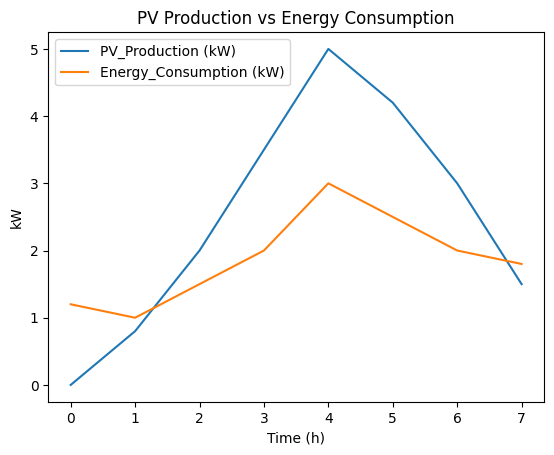

In [120]:
# Plot PV_Production and Energy_Consumption on the same line chart over time.

df.plot(x='Time (h)', y=['PV_Production (kW)', 'Energy_Consumption (kW)'], kind='line')
plt.xlabel('Time (h)')
plt.ylabel('kW')
plt.title('PV Production vs Energy Consumption')

In [121]:
#Compute the correlation between PV_Production and Solar_Irradiance.

print(df)
print()

correlation = df['Solar_Irradiance (W/m^2)'].corr(df['PV_Production (kW)'])
print(f'Correlation is: {correlation}')

if correlation > 0:
    print('There is a positive correlation between Solar_Irradiance and PV_Production.')
elif correlation < 0:
    print('There is a negative correlation between Solar_Irradiance and PV_Production.')
else:
    print('There is no correlation between Solar_Irradiance and PV_Production.')

   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
2         2                       120                 2.0   
3         3                       200                 3.5   
4         4                       300                 5.0   
5         5                       250                 4.2   
6         6                       180                 3.0   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  \
0                      1.2                15               3.0   
1                      1.0                16               3.5   
2                      1.5                18               4.0   
3                      2.0                20               5.0   
4                      3.0                22               5.5   
5                      2.5                21          

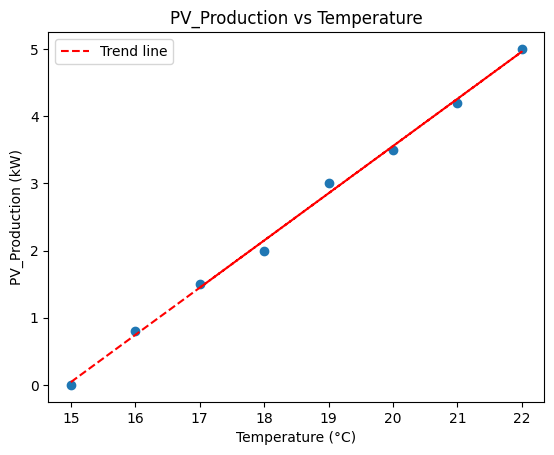

In [122]:
#Create a scatter plot of PV_Production vs Temperature and observe the trend.

plt.scatter(df['Temperature (°C)'], df['PV_Production (kW)'])
plt.xlabel('Temperature (°C)')
plt.ylabel('PV_Production (kW)')
plt.title('PV_Production vs Temperature')

z = np.polyfit(df['Temperature (°C)'], df['PV_Production (kW)'], 1)
p = np.poly1d(z)
plt.plot(df['Temperature (°C)'], p(df['Temperature (°C)']), "r--", label='Trend line')
plt.legend()

   Time (h)  Solar_Irradiance (W/m^2)  PV_Production (kW)  \
0         0                         0                 0.0   
1         1                        50                 0.8   
2         2                       120                 2.0   
3         3                       200                 3.5   
4         4                       300                 5.0   
5         5                       250                 4.2   
6         6                       180                 3.0   
7         7                       100                 1.5   

   Energy_Consumption (kW)  Temperature (°C)  Wind_Speed (m/s)  \
0                      1.2                15               3.0   
1                      1.0                16               3.5   
2                      1.5                18               4.0   
3                      2.0                20               5.0   
4                      3.0                22               5.5   
5                      2.5                21          

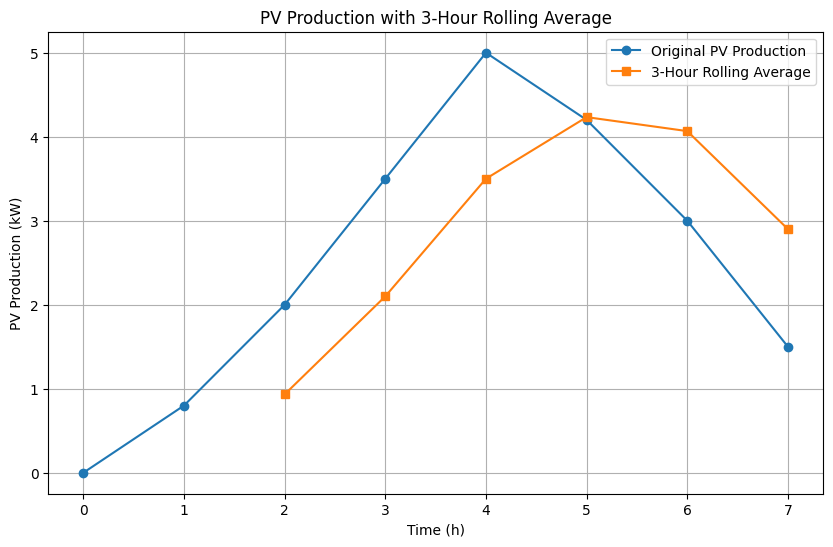

In [123]:
#Compute a 3-hour rolling average of PV_Production and add it as a new column.

df['3-Hour Rolling Average (kW)'] = df['PV_Production (kW)'].rolling(window=3).mean()
print(df)

# Plot both original and rolling average
plt.figure(figsize=(10, 6))
plt.plot(df['Time (h)'], df['PV_Production (kW)'], 'o-', label='Original PV Production')
plt.plot(df['Time (h)'], df['3-Hour Rolling Average (kW)'], 's-', label='3-Hour Rolling Average')
plt.xlabel('Time (h)')
plt.ylabel('PV Production (kW)')
plt.title('PV Production with 3-Hour Rolling Average')
plt.legend()
plt.grid(True)
plt.show()

#**Task 5: Battery Storage Optimization**

In [2]:
"""
===== Task 5: Battery Storage Optimization =====

TASKS:
1. Calculate Net_Power = Solar_Generation - Home_Load for each hour
2. Create a column Grid_Action that shows 'Export' if Net_Power > 0, 'Import' if < 0, 'Balanced' if = 0
3. Calculate total energy imported from grid and total exported to grid
4. Find the most expensive hour to buy from grid (highest price + need to import)
5. Plot Solar_Generation, Home_Load, and Grid_Price on same graph (use secondary y-axis for price)
6. Calculate potential daily savings if battery stores excess solar (assume battery charges when Net_Power > 0, discharges when < 0)
7. Identify 'peak pricing hours' (Grid_Price > 0.25) and calculate how much load occurs during these hours
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hour': np.arange(0, 24),
    'Solar_Generation_kW': [0,0,0,0,0,5,15,25,35,40,42,40,35,30,20,10,5,0,0,0,0,0,0,0],
    'Home_Load_kW': [2,1.5,1.5,1.5,2,3,4,5,6,7,8,9,8,7,6,8,10,12,11,9,7,5,4,3],
    'Grid_Price_per_kWh': [0.12,0.12,0.12,0.12,0.12,0.12,0.15,0.20,0.25,0.25,0.20,0.18,0.18,0.20,0.25,0.30,0.35,0.35,0.30,0.25,0.20,0.15,0.12,0.12]
}

df = pd.DataFrame(data)
# Battery specs: 10 kWh capacity, starts at 50% charge (5 kWh)

print(df)

    Hour  Solar_Generation_kW  Home_Load_kW  Grid_Price_per_kWh
0      0                    0           2.0                0.12
1      1                    0           1.5                0.12
2      2                    0           1.5                0.12
3      3                    0           1.5                0.12
4      4                    0           2.0                0.12
5      5                    5           3.0                0.12
6      6                   15           4.0                0.15
7      7                   25           5.0                0.20
8      8                   35           6.0                0.25
9      9                   40           7.0                0.25
10    10                   42           8.0                0.20
11    11                   40           9.0                0.18
12    12                   35           8.0                0.18
13    13                   30           7.0                0.20
14    14                   20           

In [3]:
# 1. Calculate Net_Power = Solar_Generation - Home_Load for each hour

Net_Power = df['Solar_Generation_kW'] - df['Home_Load_kW']
df['Net_Power_kW'] = Net_Power

print(df)

    Hour  Solar_Generation_kW  Home_Load_kW  Grid_Price_per_kWh  Net_Power_kW
0      0                    0           2.0                0.12          -2.0
1      1                    0           1.5                0.12          -1.5
2      2                    0           1.5                0.12          -1.5
3      3                    0           1.5                0.12          -1.5
4      4                    0           2.0                0.12          -2.0
5      5                    5           3.0                0.12           2.0
6      6                   15           4.0                0.15          11.0
7      7                   25           5.0                0.20          20.0
8      8                   35           6.0                0.25          29.0
9      9                   40           7.0                0.25          33.0
10    10                   42           8.0                0.20          34.0
11    11                   40           9.0                0.18 

In [4]:
# 2. Create a column Grid_Action that shows 'Export' if Net_Power > 0, 'Import' if < 0, 'Balanced' if = 0

df['Grid_Action'] = ['Export' if value > 0 else 'Import' if value < 0 else 'Balanced' for value in df['Net_Power_kW']]

print (df)


    Hour  Solar_Generation_kW  Home_Load_kW  Grid_Price_per_kWh  Net_Power_kW  \
0      0                    0           2.0                0.12          -2.0   
1      1                    0           1.5                0.12          -1.5   
2      2                    0           1.5                0.12          -1.5   
3      3                    0           1.5                0.12          -1.5   
4      4                    0           2.0                0.12          -2.0   
5      5                    5           3.0                0.12           2.0   
6      6                   15           4.0                0.15          11.0   
7      7                   25           5.0                0.20          20.0   
8      8                   35           6.0                0.25          29.0   
9      9                   40           7.0                0.25          33.0   
10    10                   42           8.0                0.20          34.0   
11    11                   4

In [6]:
# 3. Calculate total energy imported from grid and total exported to grid

# Import = when Net_Power is negative (need to buy from grid)
total_import = df[df['Net_Power_kW'] < 0]['Net_Power_kW'].abs().sum()

# Export = when Net_Power is positive (sell to grid)
total_export = df[df['Net_Power_kW'] > 0]['Net_Power_kW'].sum()

print(f"Total Energy Imported from Grid: {total_import} kWh")
print(f"Total Energy Exported to Grid: {total_export} kWh")

Total Energy Imported from Grid: 64.5 kWh
Total Energy Exported to Grid: 226.0 kWh


In [31]:
# 4. Find the most expensive hour to buy from grid (highest price + need to import)

# First, filter to only hours where we need to import
import_hours = df[df['Grid_Action'] == 'Import']
print("Hours where we need to import from grid:")
print(import_hours)


# Hour with the highest grid price among import hours

most_expensive_import_hour = import_hours.loc[import_hours['Grid_Price_per_kWh'].idxmax()]

print(f'\nMost expensive hour to buy from grid: ')
print(f'Hour: {most_expensive_import_hour['Hour']}')
print(f'Price: ${most_expensive_import_hour['Grid_Price_per_kWh']} /kWh')


Hours where we need to import from grid:
    Hour  Solar_Generation_kW  Home_Load_kW  Grid_Price_per_kWh  Net_Power_kW  \
0      0                    0           2.0                0.12          -2.0   
1      1                    0           1.5                0.12          -1.5   
2      2                    0           1.5                0.12          -1.5   
3      3                    0           1.5                0.12          -1.5   
4      4                    0           2.0                0.12          -2.0   
16    16                    5          10.0                0.35          -5.0   
17    17                    0          12.0                0.35         -12.0   
18    18                    0          11.0                0.30         -11.0   
19    19                    0           9.0                0.25          -9.0   
20    20                    0           7.0                0.20          -7.0   
21    21                    0           5.0                0.15     

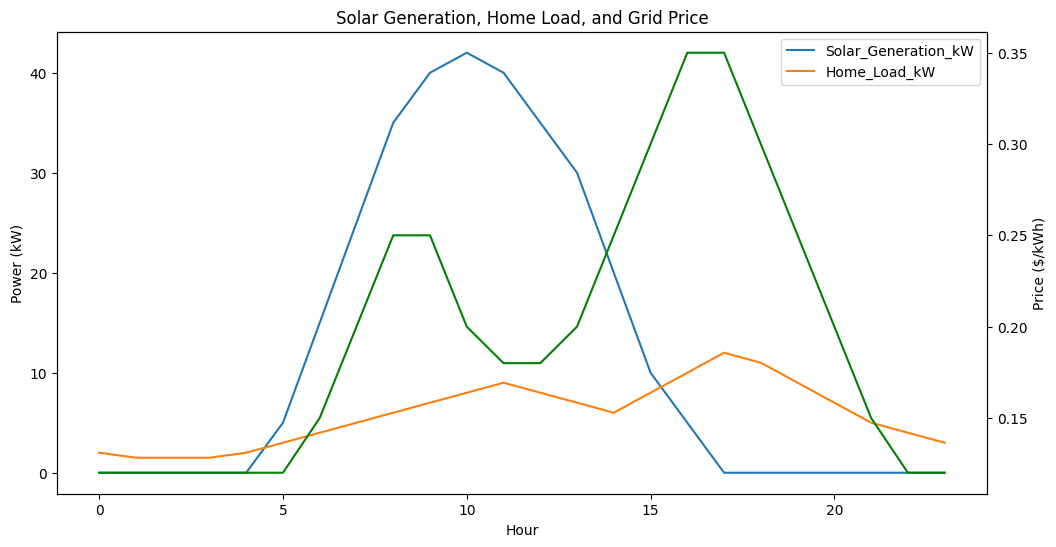

In [19]:
#5. Plot Solar_Generation, Home_Load, and Grid_Price on same graph (use secondary y-axis for price)

ax = df.plot(x='Hour', y=['Solar_Generation_kW', 'Home_Load_kW'], figsize=(12, 6))
ax.set_ylabel('Power (kW)')

ax2 = ax.twinx() #this creates secondary y-axis on a same graph
df.plot(x='Hour', y='Grid_Price_per_kWh', ax=ax2, color='green', legend=False)
ax2.set_ylabel('Price ($/kWh)')

plt.title('Solar Generation, Home Load, and Grid Price')
plt.show()

In [23]:
# 6. Calculate potential daily savings if battery stores excess solar

# Hours when we would normally import from grid (Net_Power < 0)
import_hours = df[df['Net_Power_kW'] < 0].copy()

# How much we would pay WITHOUT battery
cost_without_battery = (import_hours['Net_Power_kW'].abs() * import_hours['Grid_Price_per_kWh']).sum()

# With battery: assume we stored excess solar during surplus hours (Net_Power > 0)
# and use that stored energy instead of buying from grid
# For simplicity, assume battery can cover all deficit hours with stored surplus
stored_energy = df[df['Net_Power_kW'] > 0]['Net_Power_kW'].sum()
needed_energy = import_hours['Net_Power_kW'].abs().sum()

if stored_energy >= needed_energy:
    daily_savings = cost_without_battery
    print(f"Battery can cover all deficit hours!")
else:
    # Partially covered
    daily_savings = (stored_energy / needed_energy) * cost_without_battery
    print(f"Battery covers {stored_energy/needed_energy*100:.1f}% of deficit")

print(f"Potential Daily Savings: ${daily_savings:.2f}")

Battery can cover all deficit hours!
Potential Daily Savings: $15.51


In [30]:
#7. Identify 'peak pricing hours' (Grid_Price > 0.25) and calculate how much load occurs during these hours


peak_pricing_hours = df[df['Grid_Price_per_kWh'] > 0.25]['Hour']
print(f"Peak Pricing Hours: {peak_pricing_hours.tolist()}")

peak_load = df[df['Hour'].isin(peak_pricing_hours)]['Home_Load_kW'].sum()
print(f"Peak Load during peak pricing hours: {peak_load} kWh")

Peak Pricing Hours: [15, 16, 17, 18]
Peak Load during peak pricing hours: 41.0 kWh


#**Task 6: Wind Farm Performance Analysis**

In [2]:
"""
===== Task 6: Wind Farm Performance Analysis =====

TASKS:
1. Calculate total wind farm output (sum of all 3 turbines) for each hour
2. Calculate the capacity factor for each turbine: (Total Energy / (Rated Capacity × Hours)) × 100%
3. Find which turbine performed best (highest total energy)
4. Identify hours when wind farm is producing at >80% of total capacity (1500 kW)
5. Create a scatter plot: Wind_Speed vs Total_Output with polynomial regression (degree 3)
6. Calculate average turbine efficiency: compare actual total output vs theoretical maximum (3 × 500 kW × 24 hours)
7. Find the wind speed range (min to max) when total output exceeds 800 kW

Note: Each turbine has 500 kW rated capacity
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hour': np.arange(0, 24),
    'Wind_Speed_m_s': [4,5,6,7,8,9,10,11,12,11,10,9,8,7,6,5,6,7,8,9,10,11,9,7],
    'Turbine_1_Output_kW': [20,40,70,110,160,220,290,350,400,350,290,220,160,110,70,40,70,110,160,220,290,350,220,110],
    'Turbine_2_Output_kW': [18,38,68,105,155,215,280,340,390,340,280,215,155,105,68,38,68,105,155,215,280,340,215,105],
    'Turbine_3_Output_kW': [22,42,72,115,165,225,295,355,405,355,295,225,165,115,72,42,72,115,165,225,295,355,225,115]
}

df = pd.DataFrame(data)

print(df)

    Hour  Wind_Speed_m_s  Turbine_1_Output_kW  Turbine_2_Output_kW  \
0      0               4                   20                   18   
1      1               5                   40                   38   
2      2               6                   70                   68   
3      3               7                  110                  105   
4      4               8                  160                  155   
5      5               9                  220                  215   
6      6              10                  290                  280   
7      7              11                  350                  340   
8      8              12                  400                  390   
9      9              11                  350                  340   
10    10              10                  290                  280   
11    11               9                  220                  215   
12    12               8                  160                  155   
13    13            

    Hour  Wind_Speed_m_s  Turbine_1_Output_kW  Turbine_2_Output_kW  \
0      0               4                   20                   18   
1      1               5                   40                   38   
2      2               6                   70                   68   
3      3               7                  110                  105   
4      4               8                  160                  155   
5      5               9                  220                  215   
6      6              10                  290                  280   
7      7              11                  350                  340   
8      8              12                  400                  390   
9      9              11                  350                  340   
10    10              10                  290                  280   
11    11               9                  220                  215   
12    12               8                  160                  155   
13    13            

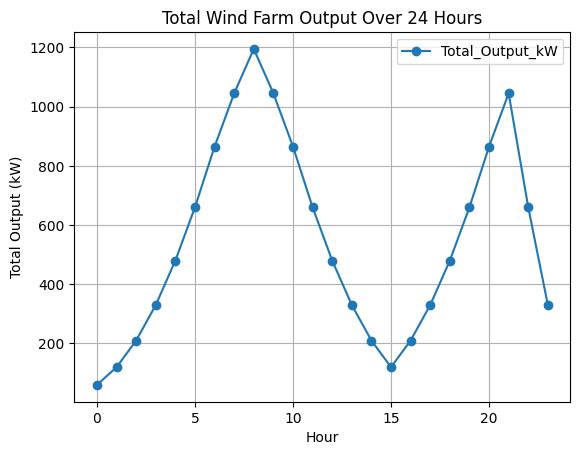

In [3]:
#1. Calculate total wind farm output (sum of all 3 turbines) for each hour

total_output = df[['Turbine_1_Output_kW', 'Turbine_2_Output_kW', 'Turbine_3_Output_kW']].sum(axis=1)
df['Total_Output_kW'] = total_output

print(df)


df.plot(x='Hour', y='Total_Output_kW', kind='line', marker='o')
plt.xlabel('Hour')
plt.ylabel('Total Output (kW)')
plt.title('Total Wind Farm Output Over 24 Hours')
plt.grid(True)

In [4]:
# 2. Calculate the capacity factor for each turbine: (Total Energy / (Rated Capacity × Hours)) × 100%

# Total energy produced by each turbine over 24 hours
turbine_1_energy = df['Turbine_1_Output_kW'].sum()
turbine_2_energy = df['Turbine_2_Output_kW'].sum()
turbine_3_energy = df['Turbine_3_Output_kW'].sum()

# Rated capacity = 500 kW per turbine
# Maximum possible energy = 500 kW × 24 hours = 12,000 kWh
rated_capacity = 500
hours = 24
max_energy = rated_capacity * hours

# Capacity factor for each turbine
capacity_factor_1 = (turbine_1_energy / max_energy) * 100
capacity_factor_2 = (turbine_2_energy / max_energy) * 100
capacity_factor_3 = (turbine_3_energy / max_energy) * 100

print(f"Turbine 1 Capacity Factor: {capacity_factor_1:.2f}%")
print(f"Turbine 2 Capacity Factor: {capacity_factor_2:.2f}%")
print(f"Turbine 3 Capacity Factor: {capacity_factor_3:.2f}%")

Turbine 1 Capacity Factor: 36.92%
Turbine 2 Capacity Factor: 35.77%
Turbine 3 Capacity Factor: 37.77%


In [5]:
# 3. Find which turbine performed best (highest total energy)

energies = [turbine_1_energy, turbine_2_energy, turbine_3_energy]
turbine_names = ['Turbine 1', 'Turbine 2', 'Turbine 3']

max_energy = max(energies)
best_turbine_index = energies.index(max_energy)
best_turbine = turbine_names[best_turbine_index]

print(f"Best performing turbine: {best_turbine} with {max_energy} kWh")


Best performing turbine: Turbine 3 with 4532 kWh


In [6]:
#4. Identify hours when wind farm is producing at >80% of total capacity (1500 kW)

# 0.8*1500 is 1200 kW

output_80 = df[df['Total_Output_kW'] > 1200]
print(output_80)


Empty DataFrame
Columns: [Hour, Wind_Speed_m_s, Turbine_1_Output_kW, Turbine_2_Output_kW, Turbine_3_Output_kW, Total_Output_kW]
Index: []


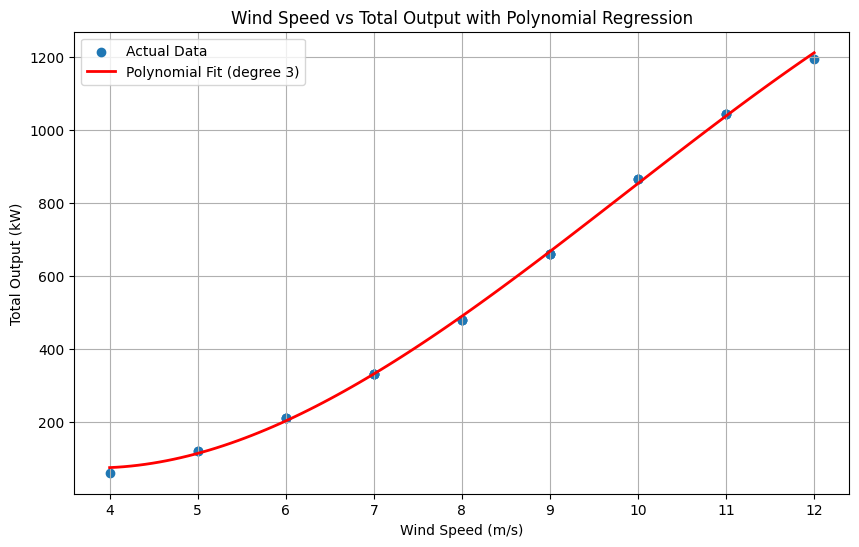

In [8]:
#5. Create a scatter plot: Wind_Speed vs Total_Output with polynomial regression (degree 3)

coefficients = np.polyfit(df['Wind_Speed_m_s'], df['Total_Output_kW'], 3)
poly_function = np.poly1d(coefficients)

# Create smooth curve
wind_speed_smooth = np.linspace(df['Wind_Speed_m_s'].min(), df['Wind_Speed_m_s'].max(), 100)
output_smooth = poly_function(wind_speed_smooth)

# Plot scatter + regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['Wind_Speed_m_s'], df['Total_Output_kW'], label='Actual Data')
plt.plot(wind_speed_smooth, output_smooth, 'r-', label='Polynomial Fit (degree 3)', linewidth=2)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Total Output (kW)')
plt.title('Wind Speed vs Total Output with Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 6. Calculate average turbine efficiency: compare actual total output vs theoretical maximum (3 × 500 kW × 24 hours)

energies = [turbine_1_energy, turbine_2_energy, turbine_3_energy]
actual_output = sum(energies)  # Use Python's built-in sum()

theoretical_maximum = 3 * 500 * 24  # 3 turbines × 500 kW × 24 hours

average_efficiency = (actual_output / theoretical_maximum) * 100

print(f"Actual Total Output: {actual_output} kWh")
print(f"Theoretical Maximum: {theoretical_maximum} kWh")
print(f"Average Turbine Efficiency: {average_efficiency:.2f}%")

Actual Total Output: 13255 kWh
Theoretical Maximum: 36000 kWh
Average Turbine Efficiency: 36.82%


In [15]:
# 7. Find the wind speed range (min to max) when total output exceeds 800 kW

output_800 = df[df['Total_Output_kW'] > 800]
print("Hours when total output exceeds 800 kW:")
print(output_800)

# Find min and max wind speed in these hours
min_wind_speed = output_800['Wind_Speed_m_s'].min()
max_wind_speed = output_800['Wind_Speed_m_s'].max()

print(f"\nWind speed range when output > 800 kW:")
print(f"Minimum: {min_wind_speed} m/s")
print(f"Maximum: {max_wind_speed} m/s")
print(f"Range: {min_wind_speed} - {max_wind_speed} m/s")

Hours when total output exceeds 800 kW:
    Hour  Wind_Speed_m_s  Turbine_1_Output_kW  Turbine_2_Output_kW  \
6      6              10                  290                  280   
7      7              11                  350                  340   
8      8              12                  400                  390   
9      9              11                  350                  340   
10    10              10                  290                  280   
20    20              10                  290                  280   
21    21              11                  350                  340   

    Turbine_3_Output_kW  Total_Output_kW  
6                   295              865  
7                   355             1045  
8                   405             1195  
9                   355             1045  
10                  295              865  
20                  295              865  
21                  355             1045  

Wind speed range when output > 800 kW:
Minimum: 10 m/s

#**Task 7: Microgrid Energy Management**

In [17]:
"""
===== Task 7: Microgrid Energy Management =====

TASKS:
1. Calculate total renewable generation (Solar + Wind) for each hour
2. Calculate Energy_Balance = (Solar + Wind + Diesel) - Community_Load
3. Identify hours when diesel generator is needed (Diesel_Generator_kW > 0)
4. Calculate renewable penetration: (Total Renewable Energy / Total Load) × 100%
5. Find the hour with maximum renewable surplus (highest positive Energy_Balance from renewables only)
6. Calculate total diesel fuel consumption assuming 1 kW = 0.3 liters/hour
7. Create a stacked area plot showing Solar, Wind, and Diesel contributions over time
8. Calculate cost savings: compare diesel cost (assume $1.5/liter) vs if all energy came from diesel
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hour': np.arange(0, 24),
    'Solar_kW': [0,0,0,0,0,8,22,45,68,85,95,98,95,85,68,45,22,8,0,0,0,0,0,0],
    'Wind_kW': [30,35,40,45,50,55,60,55,50,45,40,35,30,35,40,45,50,55,60,55,50,45,40,35],
    'Diesel_Generator_kW': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,25,40,30,20,10,0,0,0],
    'Community_Load_kW': [25,22,20,20,22,30,45,65,80,95,105,110,105,95,85,90,95,100,85,70,55,45,35,28]
}

df = pd.DataFrame(data)

print(df)

    Hour  Solar_kW  Wind_kW  Diesel_Generator_kW  Community_Load_kW
0      0         0       30                    0                 25
1      1         0       35                    0                 22
2      2         0       40                    0                 20
3      3         0       45                    0                 20
4      4         0       50                    0                 22
5      5         8       55                    0                 30
6      6        22       60                    0                 45
7      7        45       55                    0                 65
8      8        68       50                    0                 80
9      9        85       45                    0                 95
10    10        95       40                    0                105
11    11        98       35                    0                110
12    12        95       30                    0                105
13    13        85       35                    0

In [18]:
#1. Calculate total renewable generation (Solar + Wind) for each hour

total_renewable = df['Solar_kW'] + df['Wind_kW']
df['Total_Renewable_kW'] = total_renewable

print(df)

    Hour  Solar_kW  Wind_kW  Diesel_Generator_kW  Community_Load_kW  \
0      0         0       30                    0                 25   
1      1         0       35                    0                 22   
2      2         0       40                    0                 20   
3      3         0       45                    0                 20   
4      4         0       50                    0                 22   
5      5         8       55                    0                 30   
6      6        22       60                    0                 45   
7      7        45       55                    0                 65   
8      8        68       50                    0                 80   
9      9        85       45                    0                 95   
10    10        95       40                    0                105   
11    11        98       35                    0                110   
12    12        95       30                    0                105   
13    

In [19]:
#2. Calculate Energy_Balance = (Solar + Wind + Diesel) - Community_Load

energy_balance = total_renewable + df['Diesel_Generator_kW'] - df['Community_Load_kW']
df['Energy_Balance_kW'] = energy_balance

print(df)

    Hour  Solar_kW  Wind_kW  Diesel_Generator_kW  Community_Load_kW  \
0      0         0       30                    0                 25   
1      1         0       35                    0                 22   
2      2         0       40                    0                 20   
3      3         0       45                    0                 20   
4      4         0       50                    0                 22   
5      5         8       55                    0                 30   
6      6        22       60                    0                 45   
7      7        45       55                    0                 65   
8      8        68       50                    0                 80   
9      9        85       45                    0                 95   
10    10        95       40                    0                105   
11    11        98       35                    0                110   
12    12        95       30                    0                105   
13    

In [20]:
#3. Identify hours when diesel generator is needed (Diesel_Generator_kW > 0)

diesel_hours = df[df['Diesel_Generator_kW'] > 0]['Hour']
print(f"Hours when diesel generator is needed: {diesel_hours.tolist()}")

Hours when diesel generator is needed: [15, 16, 17, 18, 19, 20]


In [27]:
# 4. Calculate renewable penetration: (Total Renewable Energy / Total Load) × 100%

total_renewable = df['Solar_kW'].sum() + df['Wind_kW'].sum()
total_load = df['Community_Load_kW'].sum()

renewable_penetration = (total_renewable / total_load) * 100
print(f'Renewable penetration is: {renewable_penetration} %')

Renewable penetration is: 119.4499017681729 %


In [39]:
#5. Find the hour with maximum renewable surplus (highest positive Energy_Balance from renewables only)

renewable_energy_balance_only = df['Total_Renewable_kW'] - df['Community_Load_kW']
df['Renewable_Energy_Balance_kW'] = renewable_energy_balance_only
renewable_hours = df[df['Renewable_Energy_Balance_kW'] > 0]
max_renewable_hour = renewable_hours.loc[renewable_hours['Renewable_Energy_Balance_kW'].idxmax()]['Hour']
print(f"Hour with maximum renewable surplus: {max_renewable_hour}")

Hour with maximum renewable surplus: 8


In [31]:
#6. Calculate total diesel fuel consumption assuming 1 kW = 0.3 liters/hour

total_diesel_consumption = df['Diesel_Generator_kW'].sum() * 0.3
print(f"Total diesel fuel consumption: {total_diesel_consumption} liters")

Total diesel fuel consumption: 40.5 liters


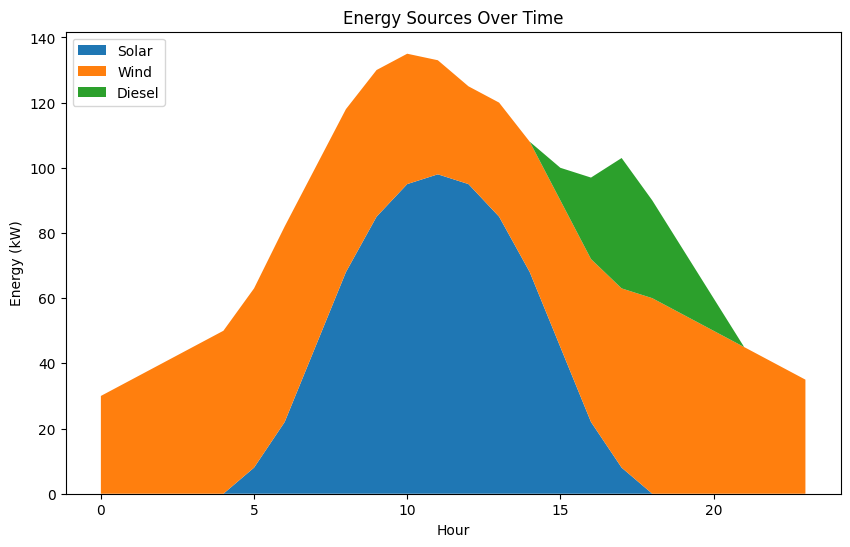

In [34]:
#7. Create a stacked area plot showing Solar, Wind, and Diesel contributions over time

plt.figure(figsize=(10, 6))
plt.stackplot(df['Hour'], df['Solar_kW'], df['Wind_kW'], df['Diesel_Generator_kW'], labels=['Solar', 'Wind', 'Diesel'])
plt.xlabel('Hour')
plt.ylabel('Energy (kW)')
plt.title('Energy Sources Over Time')
plt.legend(loc='upper left')

In [40]:
#8. Calculate cost savings: compare diesel cost (assume $1.5/liter) vs if all energy came from diesel

# Actual diesel cost (what we paid)
actual_diesel_cost = total_diesel_consumption * 1.5

# Cost if ALL energy came from diesel
total_load = df['Community_Load_kW'].sum()
diesel_needed_for_all = total_load * 0.3  # liters
cost_if_all_diesel = diesel_needed_for_all * 1.5

# Savings
cost_savings = cost_if_all_diesel - actual_diesel_cost

print(f"Actual diesel cost: ${actual_diesel_cost:.2f}")
print(f"Cost if all diesel: ${cost_if_all_diesel:.2f}")
print(f"Cost savings from renewables: ${cost_savings:.2f}")

Actual diesel cost: $60.75
Cost if all diesel: $687.15
Cost savings from renewables: $626.40


#**Task 8: EV Charging Station Analysis**

In [42]:
"""
===== Task 8: EV Charging Station Analysis =====

TASKS:
1. Calculate Total_Charging_Load_kW = EVs_Charging × Avg_Charge_Rate_kW
2. Calculate total daily energy consumed by all EVs (sum of Total_Charging_Load_kW)
3. Calculate total CO₂ emissions: Total_Charging_Load_kW × Grid_Carbon_Intensity_g_kWh (convert to kg)
4. Identify peak charging hours (when Total_Charging_Load_kW is highest)
5. Find the 'greenest' charging hours (lowest Grid_Carbon_Intensity)
6. Calculate potential emissions reduction if all charging shifted to hours with carbon intensity < 350 g/kWh
7. Plot Total_Charging_Load and Grid_Carbon_Intensity on dual-axis chart
8. Calculate average emissions per EV charge session
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Hour': np.arange(0, 24),
    'EVs_Charging': [2,1,0,0,0,1,3,8,12,10,8,6,5,4,6,8,15,20,18,12,8,6,4,3],
    'Avg_Charge_Rate_kW': [7,7,0,0,0,7,7,7,7,7,7,7,7,7,7,7,11,11,11,11,7,7,7,7],
    'Grid_Carbon_Intensity_g_kWh': [450,420,400,380,350,320,300,350,400,420,380,350,320,300,280,350,450,500,480,450,420,400,380,360]
}

df = pd.DataFrame(data)

print(df)

    Hour  EVs_Charging  Avg_Charge_Rate_kW  Grid_Carbon_Intensity_g_kWh
0      0             2                   7                          450
1      1             1                   7                          420
2      2             0                   0                          400
3      3             0                   0                          380
4      4             0                   0                          350
5      5             1                   7                          320
6      6             3                   7                          300
7      7             8                   7                          350
8      8            12                   7                          400
9      9            10                   7                          420
10    10             8                   7                          380
11    11             6                   7                          350
12    12             5                   7                      

In [43]:
#1. Calculate Total_Charging_Load_kW = EVs_Charging × Avg_Charge_Rate_kW

total_charging_load = df['EVs_Charging'] * df['Avg_Charge_Rate_kW']
df['Total_Charging_Load_kW'] = total_charging_load

print(df)

    Hour  EVs_Charging  Avg_Charge_Rate_kW  Grid_Carbon_Intensity_g_kWh  \
0      0             2                   7                          450   
1      1             1                   7                          420   
2      2             0                   0                          400   
3      3             0                   0                          380   
4      4             0                   0                          350   
5      5             1                   7                          320   
6      6             3                   7                          300   
7      7             8                   7                          350   
8      8            12                   7                          400   
9      9            10                   7                          420   
10    10             8                   7                          380   
11    11             6                   7                          350   
12    12             5   

In [52]:
#2. Calculate total daily energy consumed by all EVs (sum of Total_Charging_Load_kW)

total_daily_energy_consumed = df['Total_Charging_Load_kW'].sum()
print(f"Total daily energy consumed by all EVs: {total_daily_energy_consumed} kWh")

Total daily energy consumed by all EVs: 1380 kWh


In [48]:
#3. Calculate total CO₂ emissions: Total_Charging_Load_kW × Grid_Carbon_Intensity_g_kWh (convert to kg)

total_co2_emissions = df['Total_Charging_Load_kW'] * df['Grid_Carbon_Intensity_g_kWh'] / 1000
df['Total_CO2_Emissions_kg'] = total_co2_emissions
print(df)

    Hour  EVs_Charging  Avg_Charge_Rate_kW  Grid_Carbon_Intensity_g_kWh  \
0      0             2                   7                          450   
1      1             1                   7                          420   
2      2             0                   0                          400   
3      3             0                   0                          380   
4      4             0                   0                          350   
5      5             1                   7                          320   
6      6             3                   7                          300   
7      7             8                   7                          350   
8      8            12                   7                          400   
9      9            10                   7                          420   
10    10             8                   7                          380   
11    11             6                   7                          350   
12    12             5   

In [53]:
#4. Identify peak charging hours (when Total_Charging_Load_kW is highest)

# Find the hour with maximum charging load
peak_charging_hour = df.loc[df['Total_Charging_Load_kW'].idxmax(), 'Hour']
print(f"Peak charging hour: {peak_charging_hour}")

Peak charging hour: 17


In [55]:
#5. Find the 'greenest' charging hours (lowest Grid_Carbon_Intensity)

greenest_charging_hour = df.loc[df['Grid_Carbon_Intensity_g_kWh'].idxmin(), 'Hour']
print(f"Greenest charging hour: {greenest_charging_hour}")

Greenest charging hour: 14


In [58]:
# 6. Calculate potential emissions reduction if all charging shifted to hours with carbon intensity < 350 g/kWh

# Step 1: Calculate current total emissions
current_emissions = df['Total_CO2_Emissions_kg'].sum()

# Step 2: Find average carbon intensity during green hours (< 350 g/kWh)
green_hours = df[df['Grid_Carbon_Intensity_g_kWh'] < 350]
avg_green_carbon_intensity = green_hours['Grid_Carbon_Intensity_g_kWh'].mean()

# Step 3: Calculate hypothetical emissions if all energy was charged during green hours
total_energy = df['Total_Charging_Load_kW'].sum()
hypothetical_emissions = (total_energy * avg_green_carbon_intensity) / 1000  # Convert g to kg

# Step 4: Calculate emissions reduction
emissions_reduction = current_emissions - hypothetical_emissions

print(f"Current emissions: {current_emissions:.2f} kg")
print(f"Hypothetical emissions (green hours): {hypothetical_emissions:.2f} kg")
print(f"Potential emissions reduction: {emissions_reduction:.2f} kg")
print(f"Percentage reduction: {(emissions_reduction/current_emissions)*100:.2f}%")

Current emissions: 584.53 kg
Hypothetical emissions (green hours): 419.52 kg
Potential emissions reduction: 165.01 kg
Percentage reduction: 28.23%


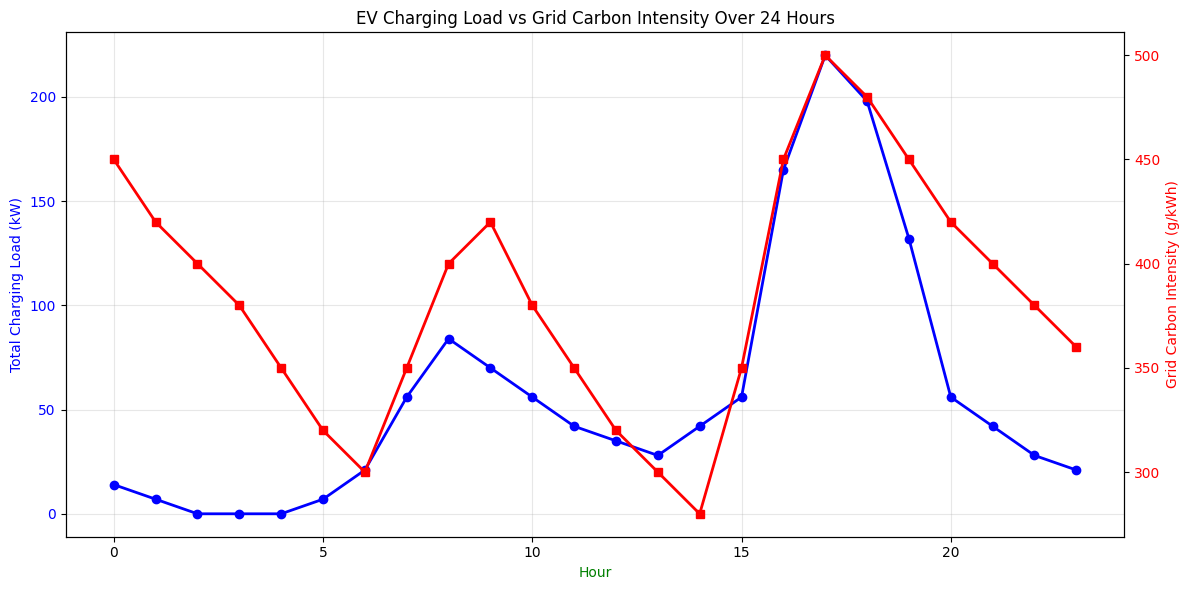

In [62]:
# 7. Plot Total_Charging_Load and Grid_Carbon_Intensity on dual-axis chart

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot charging load on left y-axis (blue)
ax1.plot(df['Hour'], df['Total_Charging_Load_kW'], 'b-o', label='Total Charging Load', linewidth=2)
ax1.set_xlabel('Hour', color='green')
ax1.set_ylabel('Total Charging Load (kW)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Create second y-axis for carbon intensity (red)
ax2 = ax1.twinx()
ax2.plot(df['Hour'], df['Grid_Carbon_Intensity_g_kWh'], 'r-s', label='Carbon Intensity', linewidth=2)
ax2.set_ylabel('Grid Carbon Intensity (g/kWh)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('EV Charging Load vs Grid Carbon Intensity Over 24 Hours')
fig.tight_layout()
plt.show()

In [64]:
#8. Calculate average emissions per EV charge session

total_emissions = df['Total_CO2_Emissions_kg'].sum()
total_charge_sessions = df['EVs_Charging'].sum()

avg_emissions_per_session = total_emissions / total_charge_sessions

print(f"Total emissions: {total_emissions:.2f} kg CO₂")
print(f"Total charge sessions: {total_charge_sessions}")
print(f"Average emissions per EV charge session: {avg_emissions_per_session:.2f} kg CO₂")

Total emissions: 584.53 kg CO₂
Total charge sessions: 160
Average emissions per EV charge session: 3.65 kg CO₂


#**Task 9: Seasonal Solar Analysis**

In [66]:
"""
===== Task 9: Seasonal Solar Analysis =====

TASKS:
1. Calculate monthly energy production (Avg_Daily_Generation × days in month - use 30 days for simplicity)
2. Calculate capacity factor for each month: (Monthly Energy / (50 kW × 24 hours × 30 days)) × 100%
3. Find best and worst performing months
4. Calculate correlation between Avg_Daily_Generation and Avg_Sunlight_Hours
5. Calculate correlation between Avg_Daily_Generation and Avg_Temperature_C
6. Plot monthly generation as bar chart with temperature as line overlay
7. Calculate annual total energy production
8. If electricity rate is $0.15/kWh, calculate annual revenue from solar

Note: System has 50 kW installed capacity
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'Avg_Daily_Generation_kWh': [85,110,145,180,210,230,225,200,165,125,90,75],
    'Avg_Sunlight_Hours': [4.5,5.5,6.8,8.2,9.5,10.2,10.0,9.0,7.5,6.0,4.8,4.2],
    'Avg_Temperature_C': [5,7,11,15,19,23,25,24,20,15,10,6]
}

df = pd.DataFrame(data)

print(df)

   Month  Avg_Daily_Generation_kWh  Avg_Sunlight_Hours  Avg_Temperature_C
0    Jan                        85                 4.5                  5
1    Feb                       110                 5.5                  7
2    Mar                       145                 6.8                 11
3    Apr                       180                 8.2                 15
4    May                       210                 9.5                 19
5    Jun                       230                10.2                 23
6    Jul                       225                10.0                 25
7    Aug                       200                 9.0                 24
8    Sep                       165                 7.5                 20
9    Oct                       125                 6.0                 15
10   Nov                        90                 4.8                 10
11   Dec                        75                 4.2                  6


In [69]:
#1. Calculate monthly energy production (Avg_Daily_Generation × days in month - use 30 days for simplicity)

Avg_Daily_Generation_kWh = df['Avg_Daily_Generation_kWh']
days_in_month = 30
monthly_energy_production = Avg_Daily_Generation_kWh * days_in_month
df['Monthly_Energy_Production_kWh'] = monthly_energy_production
print(df)

   Month  Avg_Daily_Generation_kWh  Avg_Sunlight_Hours  Avg_Temperature_C  \
0    Jan                        85                 4.5                  5   
1    Feb                       110                 5.5                  7   
2    Mar                       145                 6.8                 11   
3    Apr                       180                 8.2                 15   
4    May                       210                 9.5                 19   
5    Jun                       230                10.2                 23   
6    Jul                       225                10.0                 25   
7    Aug                       200                 9.0                 24   
8    Sep                       165                 7.5                 20   
9    Oct                       125                 6.0                 15   
10   Nov                        90                 4.8                 10   
11   Dec                        75                 4.2                  6   

In [70]:
#2. Calculate capacity factor for each month: (Monthly Energy / (50 kW × 24 hours × 30 days)) × 100%

monthly_capacity_factor = (df['Monthly_Energy_Production_kWh'] / (50 * 24 * 30)) * 100
df['Monthly_Capacity_Factor'] = monthly_capacity_factor
print(df)

   Month  Avg_Daily_Generation_kWh  Avg_Sunlight_Hours  Avg_Temperature_C  \
0    Jan                        85                 4.5                  5   
1    Feb                       110                 5.5                  7   
2    Mar                       145                 6.8                 11   
3    Apr                       180                 8.2                 15   
4    May                       210                 9.5                 19   
5    Jun                       230                10.2                 23   
6    Jul                       225                10.0                 25   
7    Aug                       200                 9.0                 24   
8    Sep                       165                 7.5                 20   
9    Oct                       125                 6.0                 15   
10   Nov                        90                 4.8                 10   
11   Dec                        75                 4.2                  6   

In [72]:
#3. Find best and worst performing months

#Best is when the capacity factor is the highest and worst is when the capacity factor is the lowest

best_month = df.loc[df['Monthly_Capacity_Factor'].idxmax(), 'Month']
worst_month = df.loc[df['Monthly_Capacity_Factor'].idxmin(), 'Month']

print(f"Best performing month: {best_month}")
print(f"Worst performing month: {worst_month}")

Best performing month: Jun
Worst performing month: Dec


In [74]:
#4. Calculate correlation between Avg_Daily_Generation and Avg_Sunlight_Hours

correlation_sunlight = df['Avg_Daily_Generation_kWh'].corr(df['Avg_Sunlight_Hours'])
print(f"Correlation between Avg_Daily_Generation and Avg_Sunlight_Hours: {correlation_sunlight}")

Correlation between Avg_Daily_Generation and Avg_Sunlight_Hours: 0.9994827044192663


In [75]:
#5. Calculate correlation between Avg_Daily_Generation and Avg_Temperature_C

correlation_temperature = df['Avg_Daily_Generation_kWh'].corr(df['Avg_Temperature_C'])
print(f'Correlation between Avg_Daily_Generation and Avg_Temperature_C: {correlation_temperature}')

Correlation between Avg_Daily_Generation and Avg_Temperature_C: 0.9232208559916709


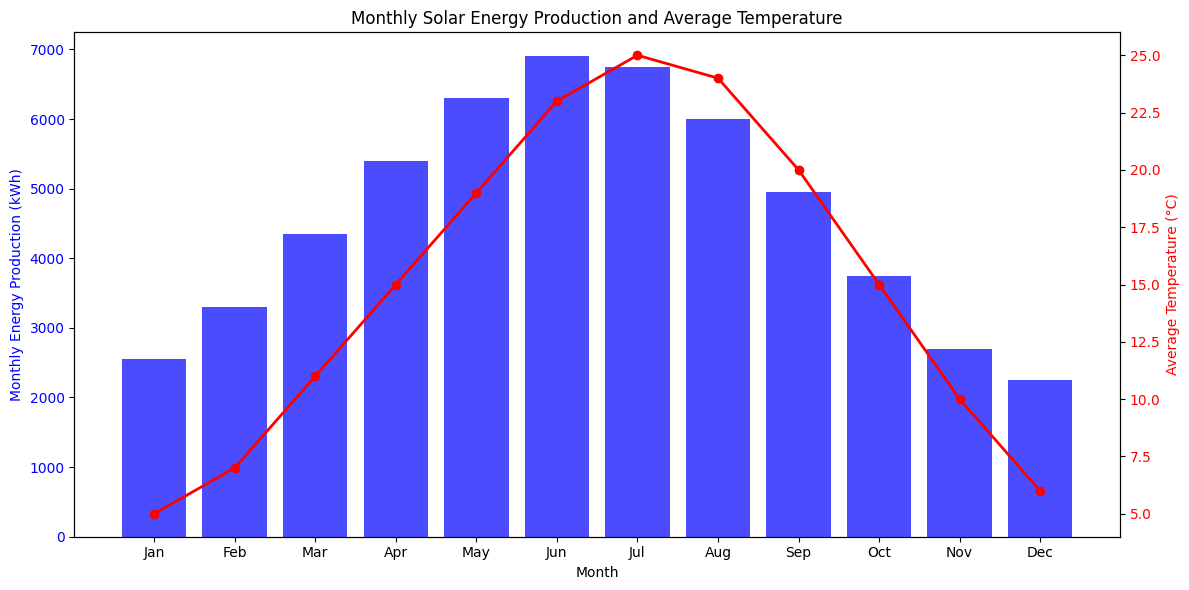

In [77]:
#6. Plot monthly generation as bar chart with temperature as line overlay

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for monthly energy production (left y-axis)
ax1.bar(df['Month'], df['Monthly_Energy_Production_kWh'], color='blue', alpha=0.7, label='Monthly Energy Production')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Energy Production (kWh)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary y-axis for temperature (right y-axis)
ax2 = ax1.twinx()
ax2.plot(df['Month'], df['Avg_Temperature_C'], color='red', marker='o', linewidth=2, label='Avg Temperature')
ax2.set_ylabel('Average Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Solar Energy Production and Average Temperature')
fig.tight_layout()
plt.show()

In [78]:
#7. Calculate annual total energy production


annual_total_energy_production = df['Monthly_Energy_Production_kWh'].sum()
print(f"Annual total energy production: {annual_total_energy_production} kWh")

Annual total energy production: 55200 kWh


In [79]:
#8. If electricity rate is $0.15/kWh, calculate annual revenue from solar

annual_revenue = annual_total_energy_production * 0.15
print(f"Annual revenue from solar: ${annual_revenue:.2f}")

Annual revenue from solar: $8280.00


#**Task 10: Energy Efficiency Analysis**

In [89]:
"""
===== Task 10: Energy Efficiency Analysis =====

TASKS:
1. Calculate monthly energy savings: Before_Upgrade - After_Upgrade
2. Calculate percentage reduction for each month
3. Calculate total annual energy savings
4. Find which month had the highest absolute savings and highest percentage savings
5. Calculate correlation between energy consumption and Heating/Cooling degree days (before and after)
6. Plot Before vs After consumption as grouped bar chart
7. If electricity costs $0.12/kWh, calculate annual cost savings
8. Calculate simple payback period if upgrade cost was $50,000
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'Before_Upgrade_kWh': [12000,11000,10000,8000,7000,9000,11000,12000,9000,8000,10000,11500],
    'After_Upgrade_kWh': [9500,8800,8000,6500,5800,7200,8800,9600,7200,6400,8000,9200],
    'Heating_Degree_Days': [850,750,600,350,150,20,0,0,100,400,650,800],
    'Cooling_Degree_Days': [0,0,5,50,180,350,450,420,220,60,10,0]
}

df = pd.DataFrame(data)

print(df)

   Month  Before_Upgrade_kWh  After_Upgrade_kWh  Heating_Degree_Days  \
0    Jan               12000               9500                  850   
1    Feb               11000               8800                  750   
2    Mar               10000               8000                  600   
3    Apr                8000               6500                  350   
4    May                7000               5800                  150   
5    Jun                9000               7200                   20   
6    Jul               11000               8800                    0   
7    Aug               12000               9600                    0   
8    Sep                9000               7200                  100   
9    Oct                8000               6400                  400   
10   Nov               10000               8000                  650   
11   Dec               11500               9200                  800   

    Cooling_Degree_Days  
0                     0  
1          

In [90]:
#1. Calculate monthly energy savings: Before_Upgrade - After_Upgrade

energy_savings = df['Before_Upgrade_kWh'] - df['After_Upgrade_kWh']
df['Energy_Savings_kWh'] = energy_savings
print(df)

   Month  Before_Upgrade_kWh  After_Upgrade_kWh  Heating_Degree_Days  \
0    Jan               12000               9500                  850   
1    Feb               11000               8800                  750   
2    Mar               10000               8000                  600   
3    Apr                8000               6500                  350   
4    May                7000               5800                  150   
5    Jun                9000               7200                   20   
6    Jul               11000               8800                    0   
7    Aug               12000               9600                    0   
8    Sep                9000               7200                  100   
9    Oct                8000               6400                  400   
10   Nov               10000               8000                  650   
11   Dec               11500               9200                  800   

    Cooling_Degree_Days  Energy_Savings_kWh  
0                

In [91]:
#2. Calculate percentage reduction for each month

percentage_reduction = ((df['Before_Upgrade_kWh'] - df['After_Upgrade_kWh']) / df['Before_Upgrade_kWh'])*100
df['Percentage_Reduction'] = percentage_reduction
print(df)

   Month  Before_Upgrade_kWh  After_Upgrade_kWh  Heating_Degree_Days  \
0    Jan               12000               9500                  850   
1    Feb               11000               8800                  750   
2    Mar               10000               8000                  600   
3    Apr                8000               6500                  350   
4    May                7000               5800                  150   
5    Jun                9000               7200                   20   
6    Jul               11000               8800                    0   
7    Aug               12000               9600                    0   
8    Sep                9000               7200                  100   
9    Oct                8000               6400                  400   
10   Nov               10000               8000                  650   
11   Dec               11500               9200                  800   

    Cooling_Degree_Days  Energy_Savings_kWh  Percentage_Reducti

In [92]:
#3. Calculate total annual energy savings

total_annual_energy_savings = df['Energy_Savings_kWh'].sum()
print(f"Total annual energy savings: {total_annual_energy_savings} kWh")

Total annual energy savings: 23500 kWh


In [93]:
#4. Find which month had the highest absolute savings and highest percentage savings

highest_abs_savings_month = df.loc[df['Energy_Savings_kWh'].idxmax(), 'Month']
highest_percent_savings_month = df.loc[df['Percentage_Reduction'].idxmax(), 'Month']

print(f"Month with highest absolute savings: {highest_abs_savings_month}")
print(f"Month with highest percentage savings: {highest_percent_savings_month}")

Month with highest absolute savings: Jan
Month with highest percentage savings: Jan


In [94]:
#5. Calculate correlation between energy consumption and Heating/Cooling degree days (before and after)

correlation_heating_before = df['Before_Upgrade_kWh'].corr(df['Heating_Degree_Days'])
correlation_cooling_before = df['Before_Upgrade_kWh'].corr(df['Cooling_Degree_Days'])

print(f"Correlation between energy consumption and Heating degree days (before upgrade): {correlation_heating_before}")
print(f"Correlation between energy consumption and Cooling degree days (before upgrade): {correlation_cooling_before}")

correlation_heating_after = df['After_Upgrade_kWh'].corr(df['Heating_Degree_Days'])
correlation_cooling_after = df['After_Upgrade_kWh'].corr(df['Cooling_Degree_Days'])

print(f"Correlation between energy consumption and Heating degree days (after upgrade): {correlation_heating_after}")
print(f"Correlation between energy consumption and Cooling degree days (after upgrade): {correlation_cooling_after}")

Correlation between energy consumption and Heating degree days (before upgrade): 0.35359553436832125
Correlation between energy consumption and Cooling degree days (before upgrade): 0.05524543404324187
Correlation between energy consumption and Heating degree days (after upgrade): 0.34698846055663984
Correlation between energy consumption and Cooling degree days (after upgrade): 0.062265935880778465


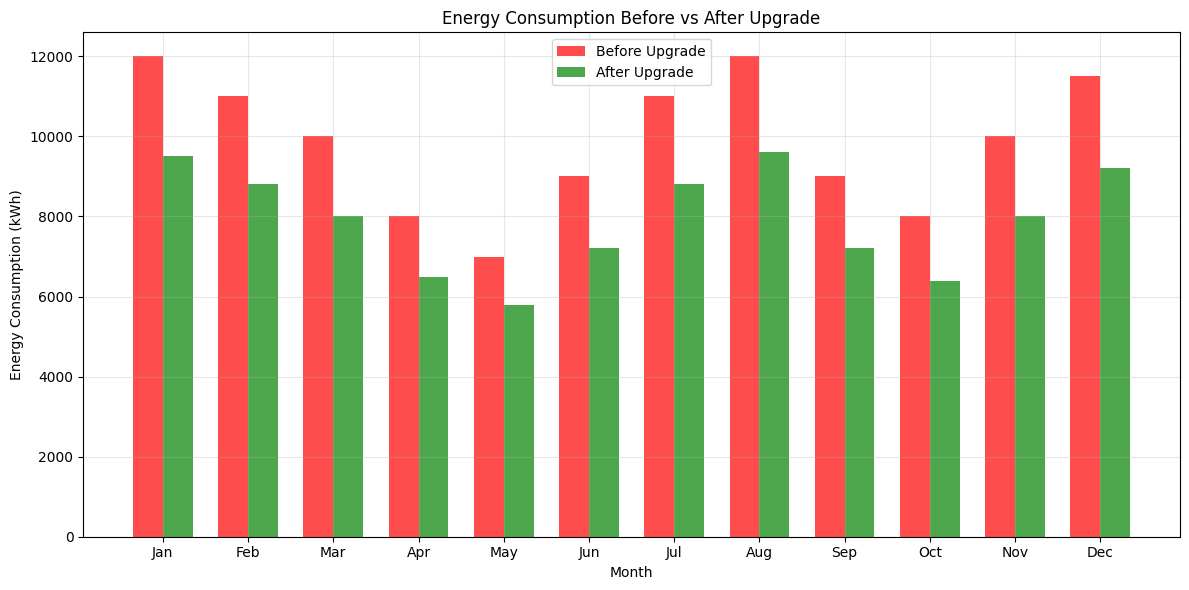

In [96]:
# 6. Plot Before vs After consumption as grouped bar chart

x = np.arange(len(df['Month']))  # Position for each month
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Before and After bars side-by-side
bars1 = ax.bar(x - width/2, df['Before_Upgrade_kWh'], width, label='Before Upgrade', color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, df['After_Upgrade_kWh'], width, label='After Upgrade', color='green', alpha=0.7)

ax.set_xlabel('Month')
ax.set_ylabel('Energy Consumption (kWh)')
ax.set_title('Energy Consumption Before vs After Upgrade')
ax.set_xticks(x)
ax.set_xticklabels(df['Month'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [99]:
#7. If electricity costs $0.12/kWh, calculate annual cost savings

annual_cost_savings = total_annual_energy_savings * 0.12
print(f"Annual cost savings: ${annual_cost_savings:.2f}")

Annual cost savings: $2820.00


In [100]:
#8. Calculate simple payback period if upgrade cost was $50,000

upgrade_cost = 50000
payback_period = upgrade_cost / annual_cost_savings
print(f"Simple payback period: {payback_period:.2f} years")

Simple payback period: 17.73 years
